In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from functools import partial
from scipy.optimize import fmin
import torch
import os, glob

from indentation.indentationset import IndentationSet
from indentation.processing.find_contact import findContact_minimum, findContact_blackMagic, findContact_blackMagic_CNN
from indentation.processing.signal import do_nothing, crop
from indentation.processing.calculate_parameters import parameter_youngs_modulus
from indentation.processing.plotting import plot_curve_parameters_bar, plot_instance_parameters_bar, plot_mean_force_curves
from indentation.ml.models import ConvClassifier_1, ConvClassifier_2

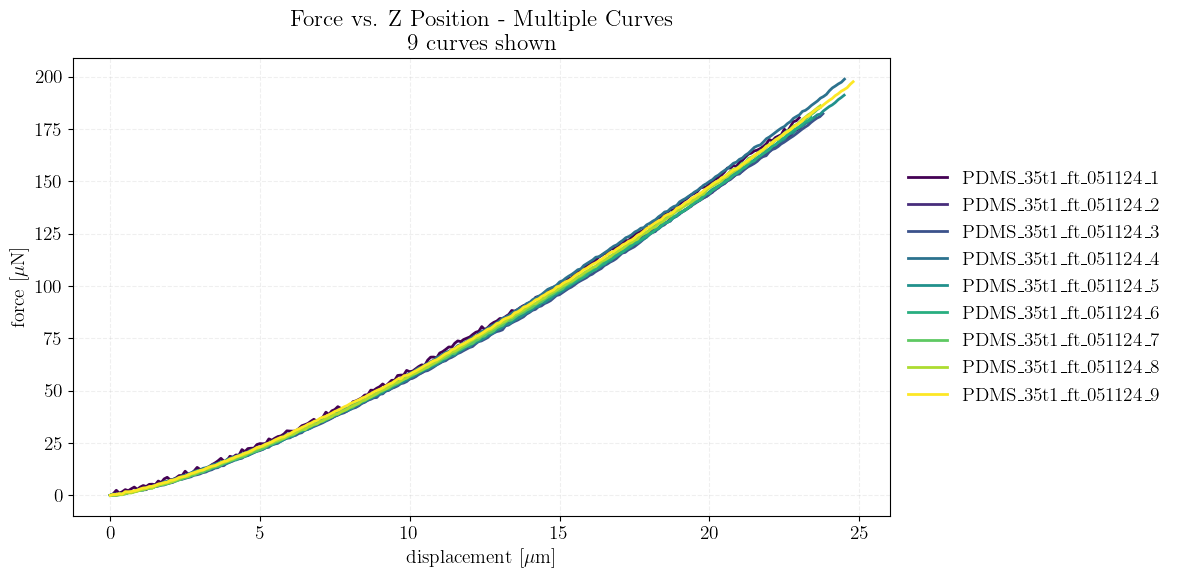

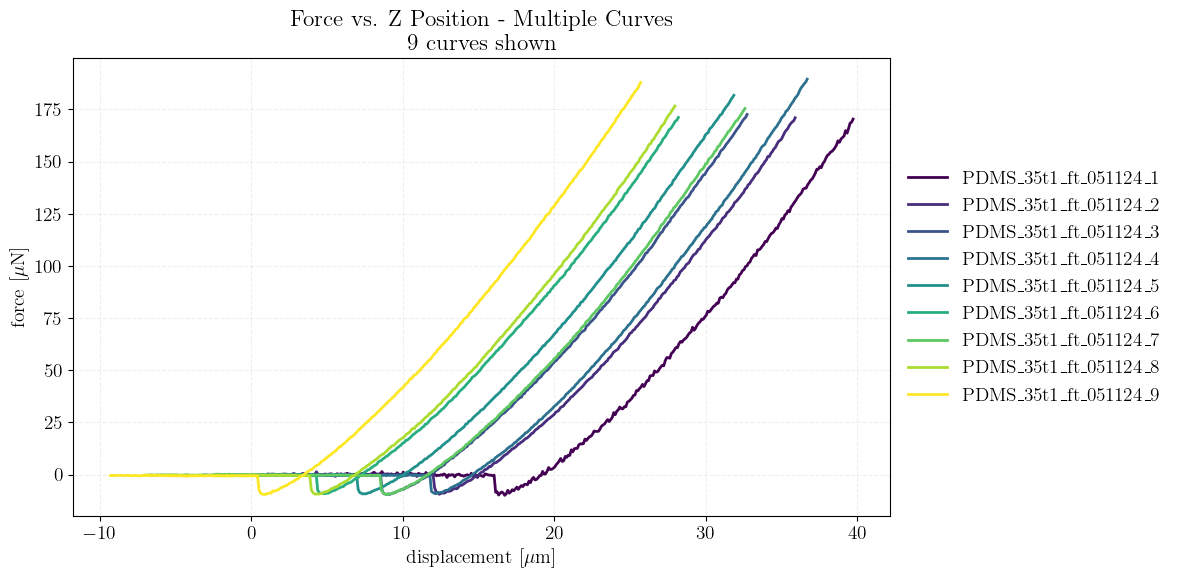

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Force vs. Z Position - Multiple Curves\n9 curves shown'}, xlabel='displacement [$\\mu$m]', ylabel='force [$\\mu$N]'>)

In [11]:
path = r"R:\Group\File_Exchange\Raoul_Paula\PDMS_35t1_ft_051124.dat"

ft = IndentationSet(path, exp_type="ft")

processing_pl = [findContact_minimum]

ft.process_raw(processing_pl)

ft.plot_all()
ft.plot_all_raw()

Text(0.5, 1.0, 'Microindentation (R = 100 um) of PDMS 35:1')

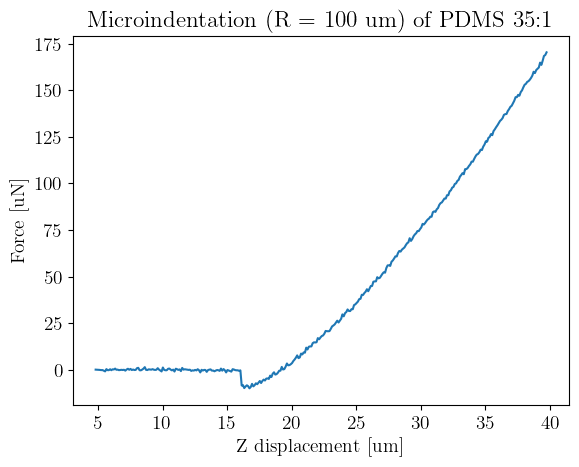

In [13]:
force = ft.data[0]["raw"]["force"] #/ 1e6
disp = -ft.data[0]["raw"]["z"] #/ 1e6
cutoff = 10
R = 100e-6

plt.plot(disp, force)
plt.ylabel("Force [uN]")
plt.xlabel("Z displacement [um]")
plt.title("Microindentation (R = 100 um) of PDMS 35:1")

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 42
         Function evaluations: 84
[180870.70770264]


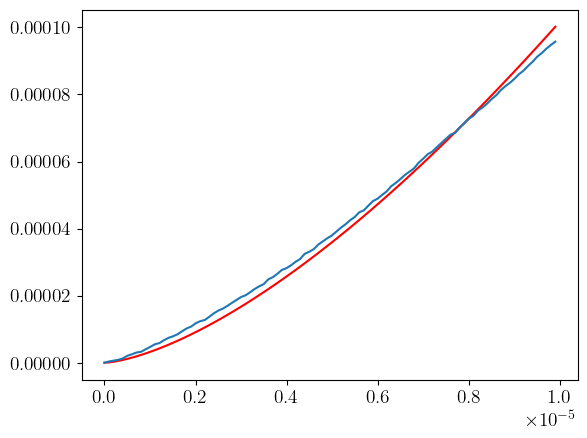

In [55]:
def hertzian_force(E, z, R):
    nu = 0.5
    F = 4.0/3.0 * E / (1-nu*nu) * np.sqrt(R) * z ** 1.5
    return F

def residuals(E, z, force, cutoff, R):
    i_max = np.where(z > cutoff / 100.0 * R)[0][0]
    force = force[0:i_max]
    z = z[0:i_max]
    
    F_hertz = hertzian_force(E, z, R)
    
    y = np.sum((force - F_hertz) ** 2)

    return y

optim_E = fmin(residuals, 1000, args=(disp, force, cutoff, R))
print(optim_E)

i_max = np.where(disp > cutoff / 100.0 * R)[0][0]
force = force[0:i_max]
disp = disp[0:i_max]
F_hertz = hertzian_force(optim_E, disp, R)

plt.figure()
plt.plot(disp, F_hertz, 'r-')
plt.plot(disp, force)
plt.show()

In [50]:
import numpy as np

def get_pdms_stiffness(ratio):
    return 1000*5.6*np.exp(-5.4*(ratio/40))

# set ratio (a value of 10 is "10:1" etc)
ratio = 35

print(get_pdms_stiffness(ratio))

49.67599789559821


Mean and std: 168.04132428492832 3.6536465746583295


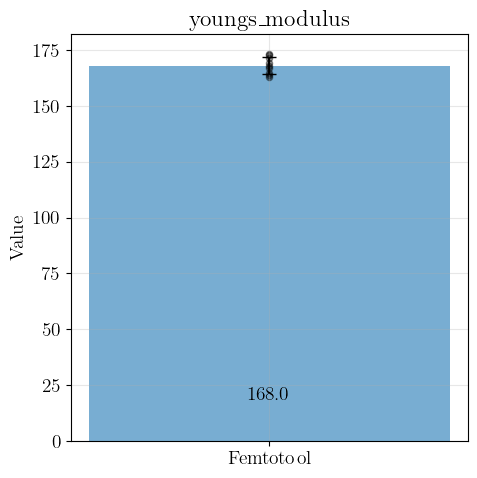

In [56]:
function_arguments = dict(radius=100, nu=0.5, cutoff=10, keyname="youngs_modulus")
ft.calculate_curve_parameter(function=parameter_youngs_modulus, **function_arguments)
plot_curve_parameters_bar(ft,
                         parameter_names=['youngs_modulus'],
                         labels=['Femtotool'],
                         figsize=(5,5))

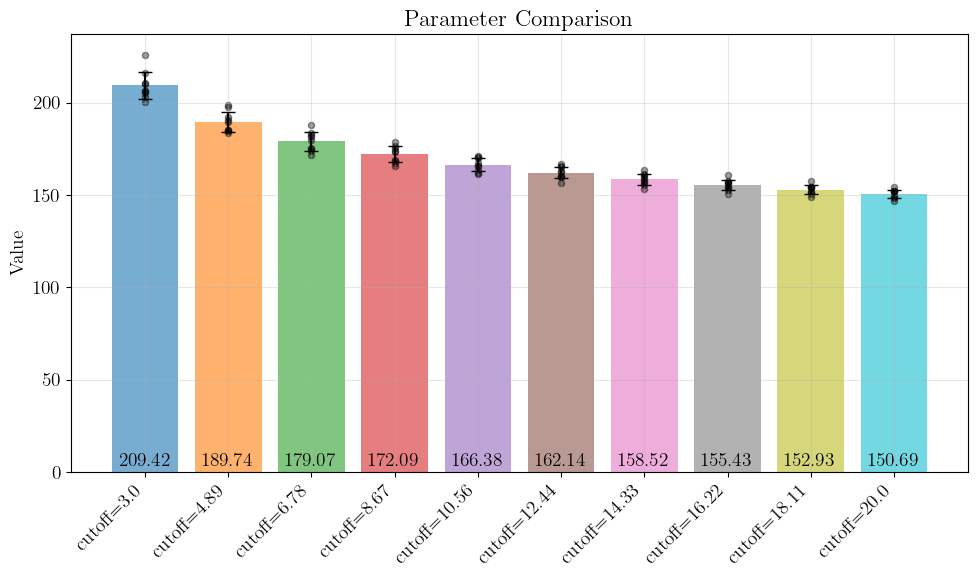

In [57]:
cutoffs = np.linspace(3, 20, 10)

for cutoff in cutoffs:
    function_arguments = dict(radius=100, nu=0.5, cutoff=cutoff, keyname="cutoff="+str(np.round(cutoff, 2)))
    ft.calculate_curve_parameter(function=parameter_youngs_modulus, **function_arguments)

plot_instance_parameters_bar(ft,
                         parameter_names=[*["cutoff="+str(np.round(cutoff, 2)) for cutoff in cutoffs]],
                         figsize=(10,6))